## Satellite Simulation Notebook
- Author Brandon Engelbrecht

In [41]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from satellite_RFI.src.satellite_sims import satellite_sim as ss
import time
import pickle
import astropy.units as u
from datetime import datetime
import tqdm
import os


import scipy as sp
import numpy as np
import pandas as pd
import scipy.optimize as opt
import matplotlib.pyplot as plt

In [3]:
obs_time_input=None#'2021 9 30 20 06 36'
# fname = '1554156377'
fname = '1551055211'


"""
Establishing the file name
"""
if obs_time_input!=None:
    obs_time_in=[int(x) for x in obs_time_input.split()]
    obs_time = datetime(obs_time_in[0], obs_time_in[1], obs_time_in[2], obs_time_in[3], obs_time_in[4], obs_time_in[5])
    dt = obs_time.strftime('%Y-%m-%d %H:%M:%S')
    fname = int((obs_time - datetime(1970, 1, 1)).total_seconds())
    print ("File name to be used is: "+str(fname))

else:
    print ("File name to be used is: "+str(fname))
    dt = (datetime.utcfromtimestamp(float(fname)).strftime('%Y-%m-%d %H:%M:%S'))
    print ("Date of observation date: "+str(dt))



File name to be used is: 1551055211
Date of observation date: 2019-02-25 00:40:11


In [4]:
katdal_info = pickle.load(open('../../../Observation_results/Untangle/'+str(fname)+'/'+str(fname)+'_katdal_info.p', 'rb'), encoding='latin1')



info = [katdal_info[i] for i in katdal_info.keys()]

nd_s0=katdal_info['nd_s0']
nd_s0_coords=katdal_info['nd_s0_coords']
frequency=katdal_info['frequency']
fs=1000
fe=1500

data_save='../../../Observation_results/Untangle/'+str(fname)+'/sat_sims/'
if os.path.exists(data_save)==False:
    os.mkdir(data_save)
    
data_mkat = '../../../Observation_results/Untangle/'+str(fname)+'/'

### ----------------------------------------------------------------------------------
Initializing

In [5]:

s_time = time.time()


sat_sims = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe])

print (time.time() - s_time)


6.9907753467559814


### --------------------------------------------------------------------------------------
Excecuting 

In [6]:
dic = {'Alpha':np.ones(71)*1}   # Parameter of ones based on the length of the satellite signals

In [7]:

s_time = time.time()


sat_sims.excecute(dic['Alpha'], obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1.5, 0.6, 0.6, 2, 1.2, 0.6, 0],  # 2000-2100sec                
            sat_info='Satellite_Catalogue/table3B_satellite_v3.csv', add_sub=[1, 1], band_lvl=[None, None])


print (time.time() - s_time)


1.7347908020019531


### ---------------------------------------------------------------------------
Multiple runnings

In [ ]:
# choice_bias = [1.5, 0.6, 0.6, 2, 1.2, 0.6, 0]

# sigma = np.arange(1,6, 1)
# bw = 25
# sims = []
# for i in tqdm.tqdm(sigma):
#     emss_b.excecute(obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
#                 file_bias_choice=choice_bias,  # 2000-2100sec                
#                 add_sub=[1, 1], band_lvl=[bw, i])
#     sims.append(emss_b.simulation_slice)
    
# sims = np.array(sims)



# x_vals = sat_sims.frequency_band[sat_sims.frequency_idx[0]:sat_sims.frequency_idx[1]]
# observation = sat_sims._asat_simsverage_over_frequency_(sat_sims.calibration_data_slice)
# simulation = sat_sims.simulation_slice

In [ ]:
# plt.figure(figsize=(10,4))

# textstr = '\n'.join([(sat+': '+str(choice_bias[i])) for i, sat in enumerate(sat_sims.satellite_type)])

# plt.plot(x_vals, observation, label=r'OBS')
# for i, sig in enumerate(sigma):
#     plt.plot(x_vals, sims[i], label=r'SIM: $\sigma-$'+str(sig)+', BW:'+str(bw)+'MHz')

# plt.text(1100, 50, textstr)
    
# plt.title('Variation in $\sigma$ values for OOB: Time-['+str(np.round(sat_sims.nd_s0[sat_sims.time_idx[0]], 2))
#           +'-'+str(np.round(sat_sims.nd_s0[sat_sims.time_idx[1]], 2))+'] seconds')



# plt.xlabel('Frequency [MHz]')
# plt.ylabel('Temperature [K] ')
# plt.legend()

# plt.tight_layout()
# plt.savefig('../../../Plots/'+fname+'_variation_in_sigma_'+str(np.round(sat_sims.nd_s0[sat_sims.time_idx[0]], 2))
#           +'-'+str(np.round(sat_sims.nd_s0[sat_sims.time_idx[1]], 2))+'_.png')

# plt.show()

### ------------------------------------------------------------------------------------------
Plotting

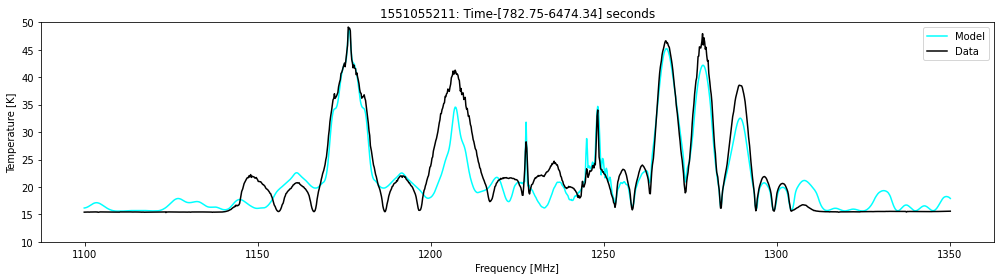

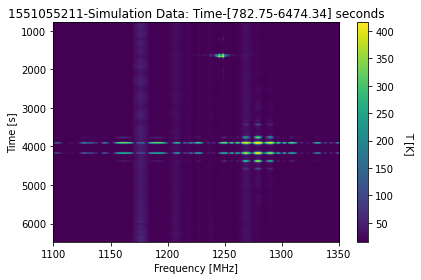

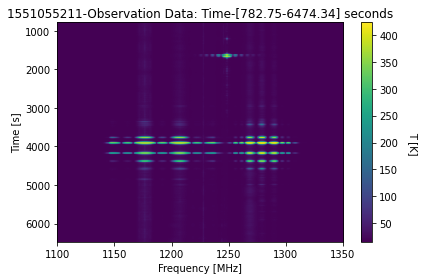

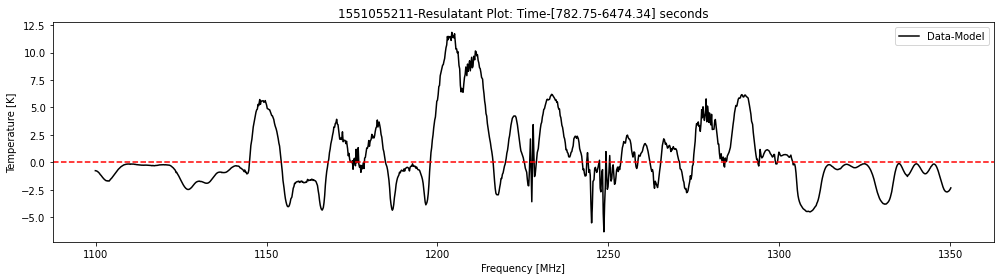

In [13]:
sat_sims.plotting(individual=None, logger=1, axis_limit=[None, None, 10, 50], tod_limit=None, save_file=None, file_type='pdf')


.

Extent values for the imshow plots

In [9]:
extent = [sat_sims.frequency_band[sat_sims.frequency_idx[0]], sat_sims.frequency_band[sat_sims.frequency_idx[1]],\
                    sat_sims.nd_s0[sat_sims.time_idx[1]], sat_sims.nd_s0[sat_sims.time_idx[0]]]

Extracting cosntellation sed

$P_{sat} = \dfrac{10^{[P_t]_i \times [G_t]_i / 10}}{4 \pi}$

Multiply a $\alpha_i$ term to the $[P_t]_i \times [G_t]_i$

.

### Setting up chi_square

Attempt 1: using the formulalism below $\\$
This $\chi^2$ is for the general amplitude multipied per constellation

$\chi^{2}$ = $\Sigma \dfrac{(O_i - E_i)^2}{E_i^2}$

In [15]:
chi2_var = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe])


In [17]:
chi2_var.excecute(dic['Alpha'], obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1.5, 0.6, 0.6, 2, 1.2, 0.6, 0],  # 2000-2100sec                
            sat_info='Satellite_Catalogue/table3B_satellite_v3.csv', add_sub=[1, 1], band_lvl=[None, None])

In [19]:
# Setting the data for the calibration slice
data = chi2_var.calibration_data_slice

# Calculating the simulation values
simulation  = chi2_var.get_simulation_slice(file_bias_choice=[0.3, 0.6, 0.6, 0.5, 0.4, 0.3, 0])[1]


$\chi^2$ function for the general amplitude, remember we are using 6 variables instead of 7 because QZS is not operating in this area

In [37]:
def chisq_func(constellations):
    """
    Chi2 function which will take in all the parameters for the satellites
    """

    simulation = chi2_var.get_simulation_slice(file_bias_choice=constellations)[1]
    data = chi2_var.calibration_data_slice
    
    chi_sq = np.sum((np.log10(simulation) - np.log10(data))**2 / np.log10(data)**2)
    return chi_sq

In [38]:
# Initial value for the chi2
choice = np.array([1.5, 0.6, 0.6, 2., 1.2, 0.6, 0])


In [43]:
# Testing the speed of the chi2

s_time = time.time()
chi2 = chisq_func(choice)
print (time.time() - s_time)

0.7500202655792236


### Using scipy.optimize.minimize

In [44]:
import scipy.optimize as opt

In [45]:
cons_NM = opt.minimize(fun=chisq_func, 
                      x0=np.array([1.5, 0.6, 0.6, 2, 1.2, 0.6, 0]), 
                      method='Nelder-Mead',
                      bounds=((0.01,2),(0.01,2),(0.1,2),(0.01,2),(0.01,2),(0.01,2),(0.0,2)),
                      tol=None,
                      options={'maxiter':1e6,
                              'xatol':1e-5,
                              'fatol':1e-5})

In [46]:
cons_PL = opt.minimize(fun=chisq_func, 
                      x0=np.array([1.5, 0.6, 0.6, 2, 1.2, 0.6, 0]), 
                      method='Powell',
                      bounds=((0.01,2),(0.01,2),(0.1,2),(0.01,2),(0.01,2),(0.01,2),(0.0,2)),
                      tol=100,
                      options={'maxiter':1e6,
                              'xtol':0.0001,
                              'ftol':0.0001})

In [47]:
cons_TNC = opt.minimize(fun=chisq_func, 
                      x0=np.array([1.5, 0.6, 0.6, 2, 1.2, 0.6, 0]), 
                      method='TNC',
                      bounds=((0.01,2),(0.01,2),(0.1,2),(0.01,2),(0.01,2),(0.01,2),(0.0,2)),
                      tol=100,
                      options={'xtol':1,
                              'ftol':1,
                              'gtol':1})

In [50]:
print (cons_NM.x)
print ('\n')
print (cons_PL.x)
print ('\n')
print (cons_TNC.x)

[0.8819558  0.69846666 0.30127809 2.         0.80263349 0.07398302
 0.00564832]


[0.89101101 0.70699264 0.31516191 1.60546511 0.79186738 0.06471136
 1.99995162]


[1.25072535 0.53048723 0.225      1.67777988 1.2023601  0.55680053
 0.        ]


In [52]:
chi2_test = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe])



In [78]:
chi2_test.excecute(dic['Alpha'], obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=cons_TNC.x,  # 2000-2100sec                
            sat_info='Satellite_Catalogue/table3B_satellite_v3.csv', add_sub=[1, 1], band_lvl=[25, None])

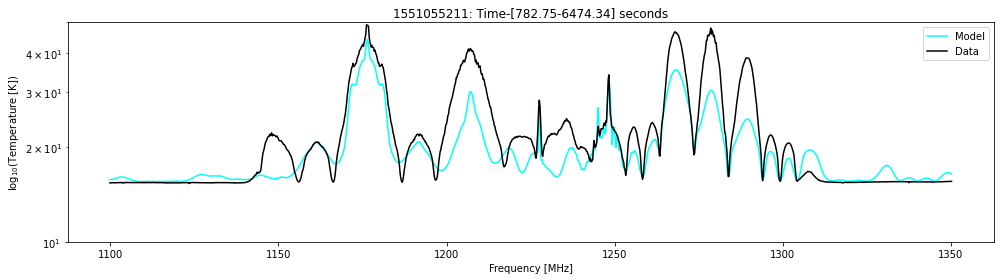

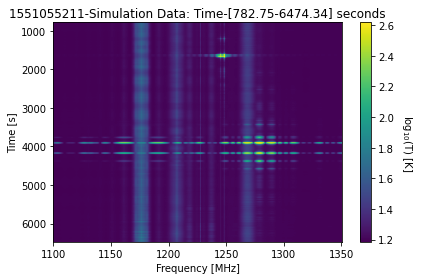

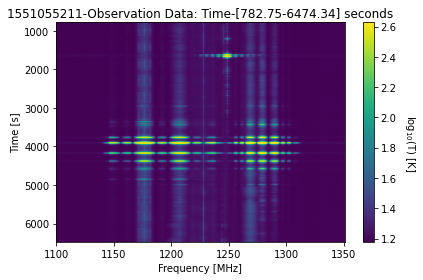

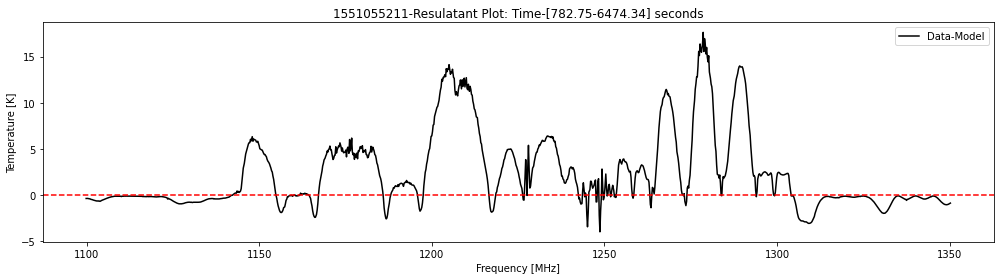

In [79]:
chi2_test.plotting(individual=None, logger=None, axis_limit=[None, None, 10, 50], tod_limit=None, save_file=None, file_type='pdf')


## Looking to use the $\chi^2$ on the follow 71 parameters

In [118]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
sat2 = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe])



array([0.36246804, 0.77673038, 0.35157313, 0.21484334, 0.20327383,
       0.41185025, 0.87926331, 0.13412684, 0.5376951 , 0.57881778,
       0.85358683, 0.42499771, 0.19817618, 0.44408338, 0.86570713,
       0.91393546, 0.22456088, 0.77056939, 0.73138397, 0.91362235,
       0.52419295, 0.5576507 , 0.42120756, 0.43441097, 0.41380745,
       0.94276535, 0.97249573, 0.89425662, 0.47305245, 0.3352308 ,
       0.20351421, 0.77058776, 0.95014838, 0.96864807, 0.73529548,
       0.8721005 , 0.89121051, 0.5763071 , 0.50250406, 0.12066849,
       0.65355067, 0.9018193 , 0.21809992, 0.06527641, 0.41840177,
       0.27535855, 0.67628575, 0.36615218, 0.84115509, 0.82091767,
       0.10904251, 0.44490323, 0.28218498, 0.74728184, 0.2314955 ,
       0.54310016, 0.68223059, 0.17463899, 0.14341263, 0.24146825,
       0.42055101, 0.11013696, 0.9399112 , 0.91042779, 0.08180517,
       0.07961397, 0.10061196, 0.6575479 , 0.27240838, 0.50038133,
       0.09803556])

In [100]:
# dic = {'Alpha':np.random.random(71)}    # Feeding a dictionary of random entries between 0 and 1
dic = {'Alpha':np.ones(71)} 

In [101]:
sat2.excecute(a_param=dic['Alpha'], obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=cons_TNC.x,
            sat_info='Satellite_Catalogue/table3B_satellite_v3.csv', add_sub=[1, 1], band_lvl=[None, None])




In [102]:
def chisq_func2(a_param):
    """
    Chi2 function which will take in all the parameters for the satellites
    """

    sat2.excecute(a_param, obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=cons_TNC.x,             
            sat_info='Satellite_Catalogue/table3B_satellite_v3.csv', add_sub=[1, 1], band_lvl=[None, None])

    
    
    simulation = sat2.simulation_TOD_slice
    data = sat2.calibration_data_slice
    
    chi_sq = np.sum((np.log10(simulation) - np.log10(data))**2 / np.log10(data)**2)
    print (chi_sq)
    return chi_sq

In [103]:
chisq_func2(dic['Alpha'])

9293.42299217479


9293.42299217479

In [97]:
x = (0.0001, 2)

In [98]:
bnds = [x for i in range(len(dic['Alpha']))]

In [109]:
signal_TNC = opt.minimize(fun=chisq_func2, 
                      x0=dic['Alpha'], 
                      method='TNC',
                      bounds=bnds,
                      tol=100,
                      options={'xtol':10,
                              'ftol':10,
                              'gtol':10,
                              'maxfun':1e4})

signal_PL = opt.minimize(fun=chisq_func2, 
                      x0=dic['Alpha'], 
                      method='Powell',
                      tol=100,
                      options={'maxiter':1e6,
                              'xtol':0.0001,
                              'ftol':0.0001})

9293.42299217479
9293.422992174837
9293.422992174772
9293.422992174781
9293.422992174781
9293.422992174528
9293.422992174528
9293.42299185039
9293.422991839863
9293.422991839863
9293.422993157688
9293.422993157688
9293.423003527765
9293.423003527765
9293.42299217479
9293.42299217479
9293.422992155603
9293.422992179041
9293.42299217479
9293.42299217479
9293.42299217479
9293.42299138463
9293.422992141508
9293.42299217479
9293.42299217479
9293.42299217479
9293.422989069382
9293.42298826532
9293.42299242199
9293.42299217479
9293.42299217479
9293.42299217479
9293.42299294348
9293.42299294348
9293.42299217479
9293.422992174783
9293.422992526523
9293.422992526523
9293.422992502849
9293.422992328473
9293.422992174783
9293.42299217479
9293.42299217479
9293.42299217479
9293.42299217479
9293.4229923319
9293.4229923319
9293.42299217479
9293.42299217479
9293.42299217479
9293.42299217479
9293.42299217479
9293.42299217479
9293.42299217479
9293.42299217479
9293.42299217479
9293.42299217479
9293.422992

TypeError: integer argument expected, got float

In [117]:
signal_PL

   direc: array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [ 9.46974605e+01,  6.19781186e+02, -4.28318821e+02, ...,
        -6.25237381e+03, -3.41638126e-01,  1.26844604e+00]])
     fun: 7764.859411437742
 message: 'Optimization terminated successfully.'
    nfev: 7644
     nit: 9
  status: 0
 success: True
       x: array([-3.56593685e+02,  1.97587165e+03, -1.90252767e+02,  3.94912039e+00,
       -1.886023

In [119]:
sat_test3 = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe])

In [120]:
sat_test3.excecute(signal_PL.x, obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1.5, 0.6, 0.6, 2, 1.2, 0.6, 0],  # 2000-2100sec                
            sat_info='Satellite_Catalogue/table3B_satellite_v3.csv', add_sub=[1, 1], band_lvl=[None, None])



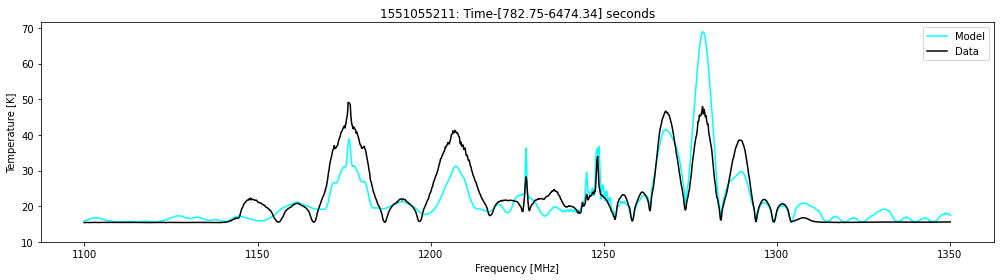

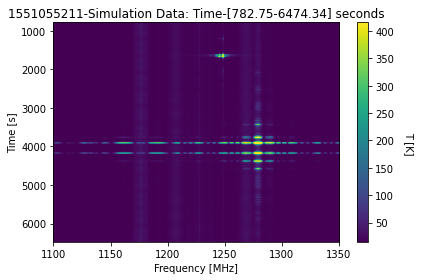

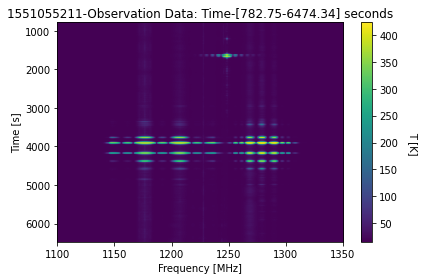

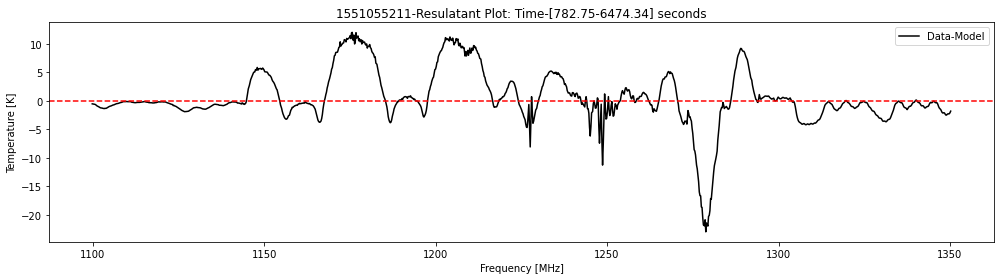

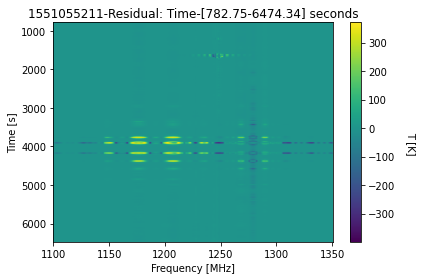

In [121]:
sat_test3.plotting(individual=None, logger=1, axis_limit=[None, None, 10, None], tod_limit=None, save_file='signal_pl', file_type='png')


In [ ]:
sat_test3_res = sat_test3.simulation_TOD_slice - sat_test3.calibration_data_slice

In [ ]:
plt.figure(figsize=(10,4))
plt.title('Observation - Simulation')
hb = plt.imshow(sat_test3_res.T, aspect='auto', extent=extent, vmin=None, vmax=None)

plt.ylabel('Time [s]')
plt.xlabel('Frequency [MHz]')

cbar = plt.colorbar(hb)
cbar.set_label(r'T [K]', rotation=270, labelpad=20, y=0.45)
plt.tight_layout()
# plt.savefig('../../../Observation_results/Untangle/Plots/1551055211/1551055211_big_chi.png')